# 3. Modelagem para inferência de risco acadêmico

Este notebook foca apenas na etapa atual do projeto: **modelagem supervisionada e inferência**.
Partimos de uma base já tratada, aplicamos o pipeline de pré-processamento,
treinamos modelos, comparamos desempenho e geramos **escore de risco de insucesso** para apoio à decisão.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, make_scorer,
    f1_score, fbeta_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

SEED = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Ambiente configurado.')
import sklearn; print(f'sklearn {sklearn.__version__} | pandas {pd.__version__}')


Ambiente configurado.
sklearn 1.8.0 | pandas 2.3.3


In [2]:
# Entrada da modelagem: base ja preparada nas etapas anteriores.
DATA_PATH = 'dados/'
OUTPUT_CSV = DATA_PATH + 'df_modelo_tratado.csv'
df_modelo_tratado = pd.read_csv(OUTPUT_CSV)

print(f'Base carregada: {df_modelo_tratado.shape[0]:,} linhas x {df_modelo_tratado.shape[1]} colunas')



Base carregada: 125,764 linhas x 48 colunas


## 1. Escopo de features para modelagem

Aqui aplicamos apenas regras necessárias para esta etapa de modelagem.
Nao repetimos transformacoes exploratorias anteriores. O objetivo e manter um conjunto de variaveis consistente para treino e inferencia.

In [3]:
# Mantemos categorias em formato original para o ColumnTransformer.
# Nao criamos dummies manualmente e removemos curso_nome da modelagem.
df_modelo_tratado = df_modelo_tratado.copy()
if 'curso_nome' in df_modelo_tratado.columns:
    df_modelo_tratado = df_modelo_tratado.drop(columns=['curso_nome'])


In [4]:
FEATURES_ALUNO = [
    'idade',
    'uf_titulo_eleitor_pb',
    'uf_naturalidade_pb',
    'primeiro_periodo',
    'sexo',
    'estado_civil',
    'raca_declarada',
    'faixa_renda_familiar',
    'forma_ingresso',
    'faixa_membros_familia',
    'sigla_centro',
    'area_conhecimento',
]

FEATURES_CURRICULO = [
    'ch_aula',
    'ch_laboratorio',
    'ch_ead',
    'ch_estagio',
    "n_aprov_antes_mesma_area",
    "n_reprov_antes_mesma_area",
    "n_tranc_desist_antes_mesma_area",
    "taxa_sucesso_count_antes_mesma_area",
    "taxa_sucesso_ch_antes_mesma_area",
    "taxa_tranc_desist_count_antes_mesma_area",
    "taxa_tranc_desist_ch_antes_mesma_area",
    "ch_integralizada_atual",
    "progresso_atual_curso",
]

FEATURES_PROFESSOR = [
    'total_docentes',
    'ano_admissao_medio',
    'prop_feminino',
    'prop_de',
    'prop_t40',
    'prop_t20',
]

ALL_FEATURES = [
    f for f in FEATURES_ALUNO + FEATURES_CURRICULO + FEATURES_PROFESSOR
    if f in df_modelo_tratado.columns
]

# Garantia extra: curso_nome fica fora da modelagem
ALL_FEATURES = [f for f in list(dict.fromkeys(ALL_FEATURES)) if f != 'curso_nome']
print(f'Total de features selecionadas: {len(ALL_FEATURES)}')


Total de features selecionadas: 22


In [5]:
print('Resumo das features selecionadas para modelagem:')
print(f'- Total: {len(ALL_FEATURES)}')
print(f'- Numericas candidatas: {len([c for c in ALL_FEATURES if c in df_modelo_tratado.select_dtypes(include=["number"]).columns])}')
print(f'- Categoricas candidatas: {len([c for c in ALL_FEATURES if c in df_modelo_tratado.select_dtypes(include=["object", "category", "bool"]).columns])}')

pd.Series(ALL_FEATURES, name='feature').to_frame().head(15)

Resumo das features selecionadas para modelagem:
- Total: 22
- Numericas candidatas: 14
- Categoricas candidatas: 8


,feature
0,idade
1,primeiro_periodo
2,sexo
3,estado_civil
4,raca_declarada
5,faixa_renda_familiar
6,forma_ingresso
7,faixa_membros_familia
8,sigla_centro
9,area_conhecimento


## 2. Pipeline de pre-processamento

O pipeline separa automaticamente variaveis numericas e categoricas:
- numericas: imputacao pela mediana + normalizacao (`StandardScaler`);
- categoricas: imputacao pela moda + codificacao one-hot.

Isso garante compatibilidade de escala e evita transformacoes manuais redundantes.

In [6]:
X = df_modelo_tratado[ALL_FEATURES].copy()
y = df_modelo_tratado['target'].copy()

FEAT_NUM = X.select_dtypes(include=['number']).columns.tolist()
FEAT_CAT = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Normalizacao apenas em variaveis numericas para compatibilizar escalas
# (ex.: carga horaria, contagens e proporcoes) e evitar distorcao por magnitude.
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

transformers = []
if FEAT_NUM:
    transformers.append(('num', num_pipeline, FEAT_NUM))
if FEAT_CAT:
    transformers.append(('cat', cat_pipeline, FEAT_CAT))

preprocessor = ColumnTransformer(transformers=transformers)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}')
print(f'Numericas normalizadas ({len(FEAT_NUM)}): {FEAT_NUM}')
print(f'Categoricas para one-hot ({len(FEAT_CAT)}): {FEAT_CAT}')
print(f'Nulos em X: {X.isnull().sum().sum()}')

Treino: 100,611 | Teste: 25,153
Numericas normalizadas (14): ['idade', 'primeiro_periodo', 'ch_aula', 'ch_laboratorio', 'ch_ead', 'n_aprov_antes_mesma_area', 'n_reprov_antes_mesma_area', 'n_tranc_desist_antes_mesma_area', 'taxa_sucesso_count_antes_mesma_area', 'taxa_sucesso_ch_antes_mesma_area', 'taxa_tranc_desist_count_antes_mesma_area', 'taxa_tranc_desist_ch_antes_mesma_area', 'ch_integralizada_atual', 'progresso_atual_curso']
Categoricas para one-hot (8): ['sexo', 'estado_civil', 'raca_declarada', 'faixa_renda_familiar', 'forma_ingresso', 'faixa_membros_familia', 'sigla_centro', 'area_conhecimento']
Nulos em X: 0


## 4. Treinamento e comparação de modelos

Nesta etapa testamos modelos com perfis complementares:
- um **baseline** (Dummy) para referência mínima;
- modelos lineares e de árvore para comparação de comportamento;
- ensembles (Random Forest, Gradient Boosting e XGBoost) para ganho de performance.

A avaliação combina métricas de classificação no teste e validação cruzada (F1),
priorizando equilíbrio entre detecção de insucesso e estabilidade do modelo.

In [7]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / max(pos, 1)

modelos = {
    'Baseline (Dummy)'   : DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Arvore de Decisao'  : DecisionTreeClassifier(max_depth=8, random_state=SEED, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'XGBoost'            : XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='logloss', scale_pos_weight=scale_pos)
}

resultados = []
pipelines_treinados = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)



In [8]:
for nome, modelo in modelos.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', modelo)])
    pipe.fit(X_train, y_train)

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(modelo, 'predict_proba') else np.zeros(len(y_test))
    cv_sc_recall = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=make_scorer(recall_score, pos_label=0, zero_division=0),
        n_jobs=-1
    )
    cv_sc_f2 = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=make_scorer(fbeta_score, beta=2, pos_label=0, zero_division=0),
        n_jobs=-1
    )

    # Métricas da classe de risco (target=0)
    recall_risco = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    precisao_risco = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    f2_risco = fbeta_score(y_test, y_pred, beta=2, pos_label=0, zero_division=0)

    resultados.append({
        'Modelo'                      : nome,
        'Acuracia'                    : accuracy_score(y_test, y_pred),
        'Precisao'                    : precision_score(y_test, y_pred, zero_division=0),   # classe 1 (sucesso)
        'Recall'                      : recall_score(y_test, y_pred, zero_division=0),       # classe 1 (sucesso)
        'Precisao Risco (classe 0)'   : precisao_risco,
        'Recall Risco (classe 0)'     : recall_risco,
        'F2-Score Risco (classe 0)'   : f2_risco,
        'F1-Score'                    : f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC'                     : roc_auc_score(y_test, y_proba) if y_proba.sum() > 0 else 0.5,
        'Recall Risco CV Medio'       : cv_sc_recall.mean(),
        'Recall Risco CV Std'         : cv_sc_recall.std(),
        'F2 Risco CV Medio'           : cv_sc_f2.mean(),
        'F2 Risco CV Std'             : cv_sc_f2.std()
    })

    pipelines_treinados[nome] = pipe
    print(
        f'{nome:<25} '
        f'F1={f1_score(y_test, y_pred, zero_division=0):.4f}  '
        f'Recall_Risco={recall_risco:.4f}  '
        f'F2_Risco={f2_risco:.4f}  '
        f'AUC={roc_auc_score(y_test, y_proba) if y_proba.sum() > 0 else 0.5:.4f}'
    )


Baseline (Dummy)          F1=0.8772  Recall_Risco=0.0000  F2_Risco=0.0000  AUC=0.5000
Regressao Logistica       F1=0.8911  Recall_Risco=0.8442  F2_Risco=0.7788  AUC=0.9089
Arvore de Decisao         F1=0.9209  Recall_Risco=0.8617  F2_Risco=0.8179  AUC=0.9342
Random Forest             F1=0.9467  Recall_Risco=0.7752  F2_Risco=0.7855  AUC=0.9564
Gradient Boosting         F1=0.9409  Recall_Risco=0.7550  F2_Risco=0.7648  AUC=0.9430
XGBoost                   F1=0.9403  Recall_Risco=0.8817  F2_Risco=0.8512  AUC=0.9616


In [9]:

df_resultados = pd.DataFrame(resultados)
display(
    df_resultados.sort_values('Recall Risco (classe 0)', ascending=False).style.highlight_max(
        subset=[
            'Acuracia', 'Precisao', 'Recall',
            'Precisao Risco (classe 0)', 'Recall Risco (classe 0)', 'F2-Score Risco (classe 0)',
            'F1-Score', 'AUC-ROC', 'Recall Risco CV Medio', 'F2 Risco CV Medio'
        ],
        color='#b3d9a3'
    )
)

,Modelo,Acuracia,Precisao,Recall,Precisao Risco (classe 0),Recall Risco (classe 0),F2-Score Risco (classe 0),F1-Score,AUC-ROC,Recall Risco CV Medio,Recall Risco CV Std,F2 Risco CV Medio,F2 Risco CV Std
5,XGBoost,0.909076,0.965124,0.916747,0.747803,0.881679,0.851202,0.940314,0.961571,0.875358,0.005421,0.845585,0.004612
2,Arvore de Decisao,0.880968,0.958139,0.886367,0.679811,0.861687,0.817921,0.920856,0.934218,0.859635,0.003329,0.817680,0.003425
1,Regressao Logistica,0.839900,0.950571,0.838685,0.594370,0.844238,0.778761,0.891130,0.908945,0.841369,0.005618,0.778127,0.005151
3,Random Forest,0.915994,0.938187,0.955422,0.829605,0.775173,0.785480,0.946726,0.956355,0.771664,0.005929,0.781294,0.005238
4,Gradient Boosting,0.906810,0.932610,0.949316,0.806602,0.754998,0.764784,0.940889,0.943038,0.757985,0.007766,0.765706,0.007364
0,Baseline (Dummy),0.781259,0.781259,1.000000,0.000000,0.000000,0.000000,0.877198,0.500000,0.000000,0.000000,0.000000,0.000000


## 5. Diagnóstico de desempenho

Os gráficos abaixo mostram desempenho por métrica, erro de classificação e separação entre classes.
Isso ajuda a escolher o modelo final não apenas pelo melhor número isolado,
mas também por consistência e comportamento em cenários de decisão.

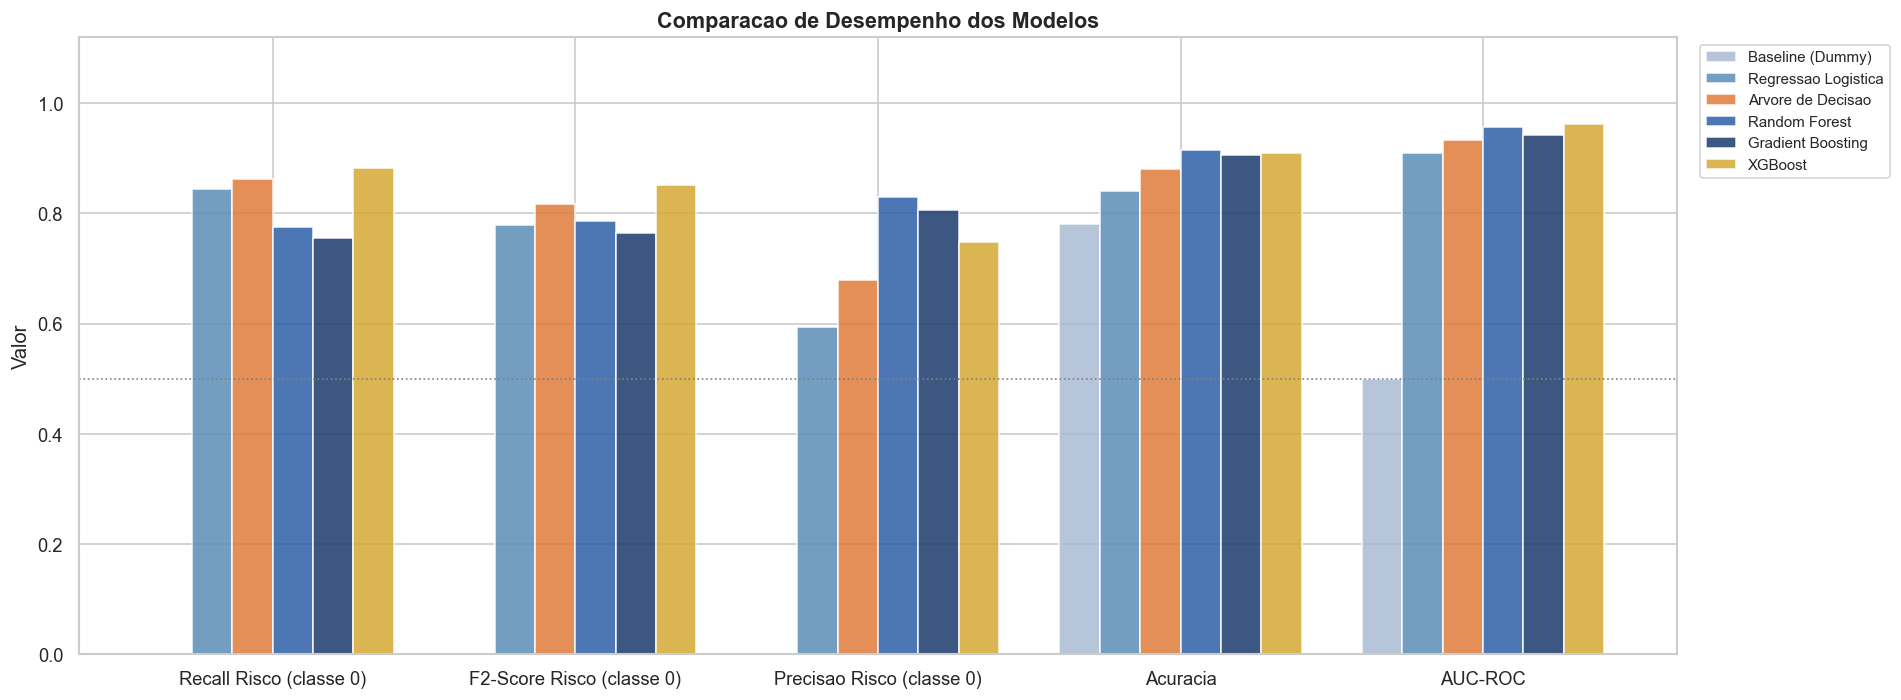

In [10]:
metricas = ['Recall Risco (classe 0)', 'F2-Score Risco (classe 0)', 'Precisao Risco (classe 0)', 'Acuracia', 'AUC-ROC']
colors_modelos = ['#AABBD4', '#5B8DB8', '#E07B3A', '#2E5EA8', '#1A3A6B', '#D4A832']

n = len(df_resultados)
x = np.arange(len(metricas))
width = 0.8 / max(n, 1)

fig, ax = plt.subplots(figsize=(16, 6))

for i, (_, row) in enumerate(df_resultados.iterrows()):
    offset = (i - (n - 1) / 2) * width
    vals = [row[m] for m in metricas]
    ax.bar(
        x + offset,
        vals,
        width,
        label=row['Modelo'],
        color=colors_modelos[i % len(colors_modelos)],
        alpha=0.85,
    )

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Valor')
ax.set_title('Comparacao de Desempenho dos Modelos', fontweight='bold', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(0.5, color='gray', linestyle=':', lw=1)

plt.tight_layout()
plt.savefig('img/fig11_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

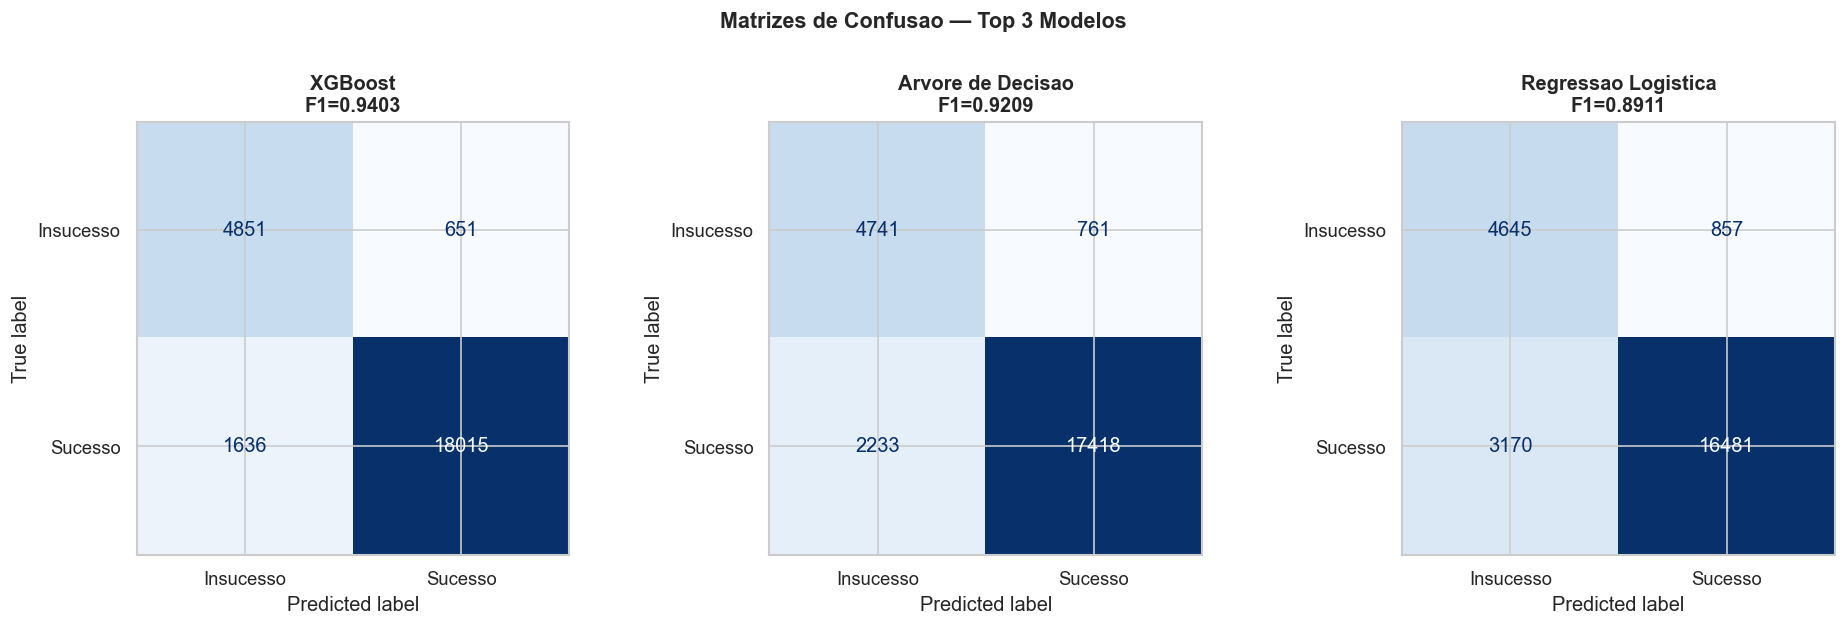

In [11]:
top3 = df_resultados.nlargest(3,'Recall Risco (classe 0)')['Modelo'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, nome in zip(axes, top3):
    y_pred = pipelines_treinados[nome].predict(X_test)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Insucesso','Sucesso']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nome}\nF1={f1_score(y_test,y_pred,zero_division=0):.4f}', fontweight='bold')
plt.suptitle('Matrizes de Confusao — Top 3 Modelos', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('img/fig12_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

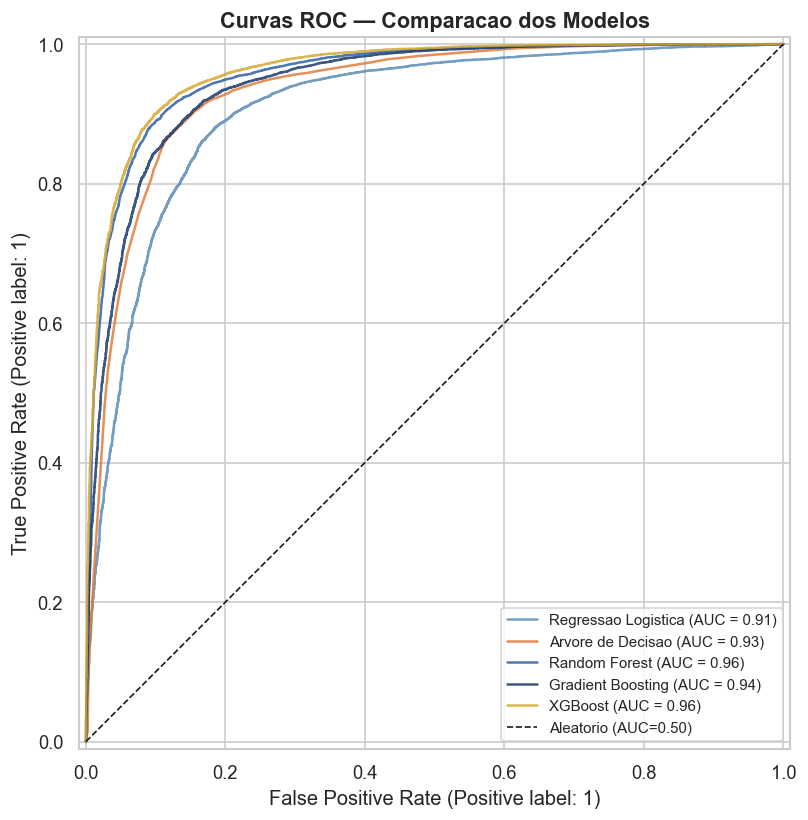

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
for i, (nome, pipe) in enumerate(pipelines_treinados.items()):
    if nome == 'Baseline (Dummy)': continue
    if hasattr(pipe.named_steps['classifier'], 'predict_proba'):
        RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax,
                                        name=nome, color=colors_modelos[i], alpha=0.85)
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.50)')
ax.set_title('Curvas ROC — Comparacao dos Modelos', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('img/fig13_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

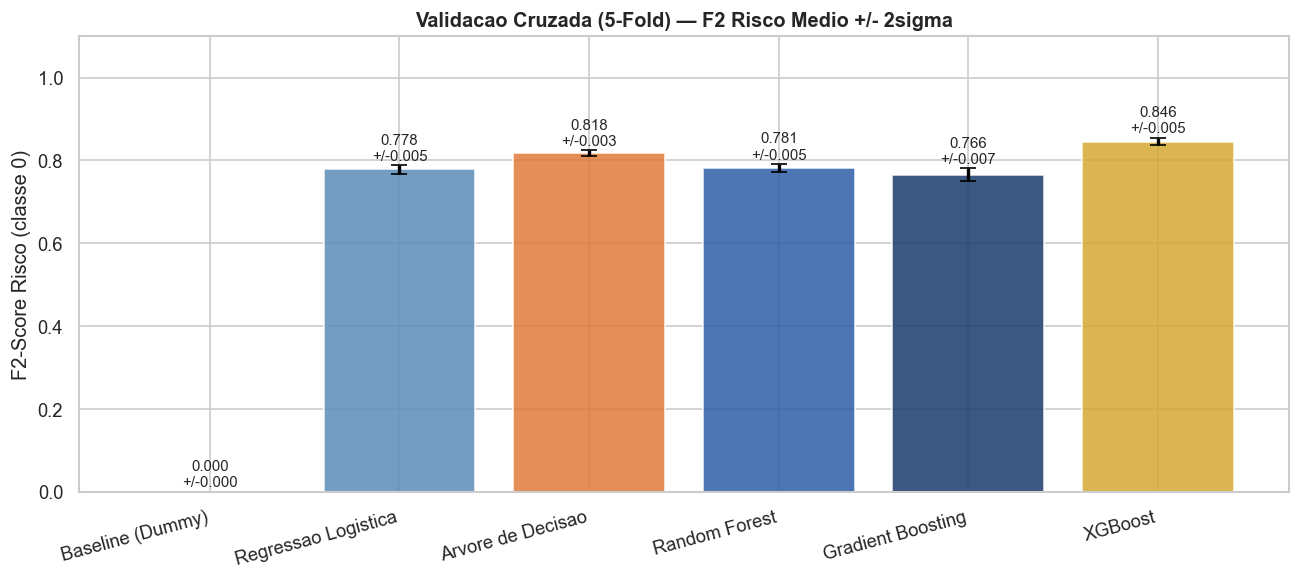

Melhor modelo: XGBoost
              precision    recall  f1-score   support

   Insucesso       0.75      0.88      0.81      5502
     Sucesso       0.97      0.92      0.94     19651

    accuracy                           0.91     25153
   macro avg       0.86      0.90      0.87     25153
weighted avg       0.92      0.91      0.91     25153



In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
nomes  = df_resultados['Modelo']
medias = df_resultados['F2 Risco CV Medio']
stds   = df_resultados['F2 Risco CV Std']
bars = ax.bar(nomes, medias, color=colors_modelos[:len(nomes)], alpha=0.85)
ax.errorbar(nomes, medias, yerr=stds*2, fmt='none', color='black', capsize=5, lw=2)
for bar, val, std in zip(bars, medias, stds):
    ax.text(bar.get_x()+bar.get_width()/2, val+std*2+0.005,
            f'{val:.3f}\n+/-{std:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('F2-Score Risco (classe 0)')
ax.set_title('Validacao Cruzada (5-Fold) — F2 Risco Medio +/- 2sigma', fontweight='bold')
ax.set_ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('img/fig14_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

melhor = df_resultados.loc[df_resultados['F2-Score Risco (classe 0)'].idxmax(), 'Modelo']
print(f'Melhor modelo: {melhor}')
print(classification_report(y_test, pipelines_treinados[melhor].predict(X_test),
                             target_names=['Insucesso','Sucesso']))

## 6. Inferência: probabilidade e faixas de risco

O treino continua binário (`target=1` sucesso; `target=0` insucesso),
mas na inferência usamos probabilidade para priorização de acompanhamento.

No pipeline atual:
- `predict_proba[:, 1]` representa **P(sucesso | X)**;
- o risco modelado de insucesso é **1 - P(sucesso)**.

A conversão para faixas (`baixo`, `medio`, `alto`) é uma regra de decisão.
Neste notebook usamos tercis para exemplo, mas os limites podem ser definidos por política institucional.


In [14]:
pipe_melhor = pipelines_treinados[melhor]
# target: 1 = sucesso (aprovado etc.) → coluna 1 de predict_proba
p_sucesso = pipe_melhor.predict_proba(X_test)[:, 1]
p_reprov = 1.0 - p_sucesso

risk_df = pd.DataFrame({
    'p_sucesso': p_sucesso,
    'p_reprovacao_modelada': p_reprov,
    'y_real': y_test.values,
})

# Tercis de risco no teste (ajuste q=4 para quartis, ou use pd.cut com limites fixos)
risk_df['faixa_risco'] = pd.qcut(
    risk_df['p_reprovacao_modelada'],
    q=4,
    labels=['baixo', 'moderado baixo', 'moderado alto', 'alto'],
    duplicates='drop',
)

resumo = (
    risk_df.groupby('faixa_risco', observed=True)
    .agg(
        n=('y_real', 'count'),
        taxa_sucesso_real=('y_real', 'mean'),
        p_reprov_media=('p_reprovacao_modelada', 'mean'),
    )
    .assign(taxa_insucesso_real=lambda d: 1.0 - d['taxa_sucesso_real'])
    .drop(columns=['taxa_sucesso_real'])
    .round(4)
)
display(resumo)
print('Contagem por faixa:')
print(risk_df['faixa_risco'].value_counts().sort_index())


,n,p_reprov_media,taxa_insucesso_real
faixa_risco,,,
baixo,6289,0.0069,0.0035
moderado baixo,6288,0.0440,0.0126
moderado alto,6288,0.2252,0.0959
alto,6288,0.8823,0.7630


Contagem por faixa:
faixa_risco
baixo             6289
moderado baixo    6288
moderado alto     6288
alto              6288
Name: count, dtype: int64


## 7. Interpretabilidade para apoio à inferência

Após escolher o modelo, avaliamos quais variáveis mais influenciam a predição.
Isso ajuda na interpretação pedagógica dos resultados e na comunicação com gestores e coordenações.

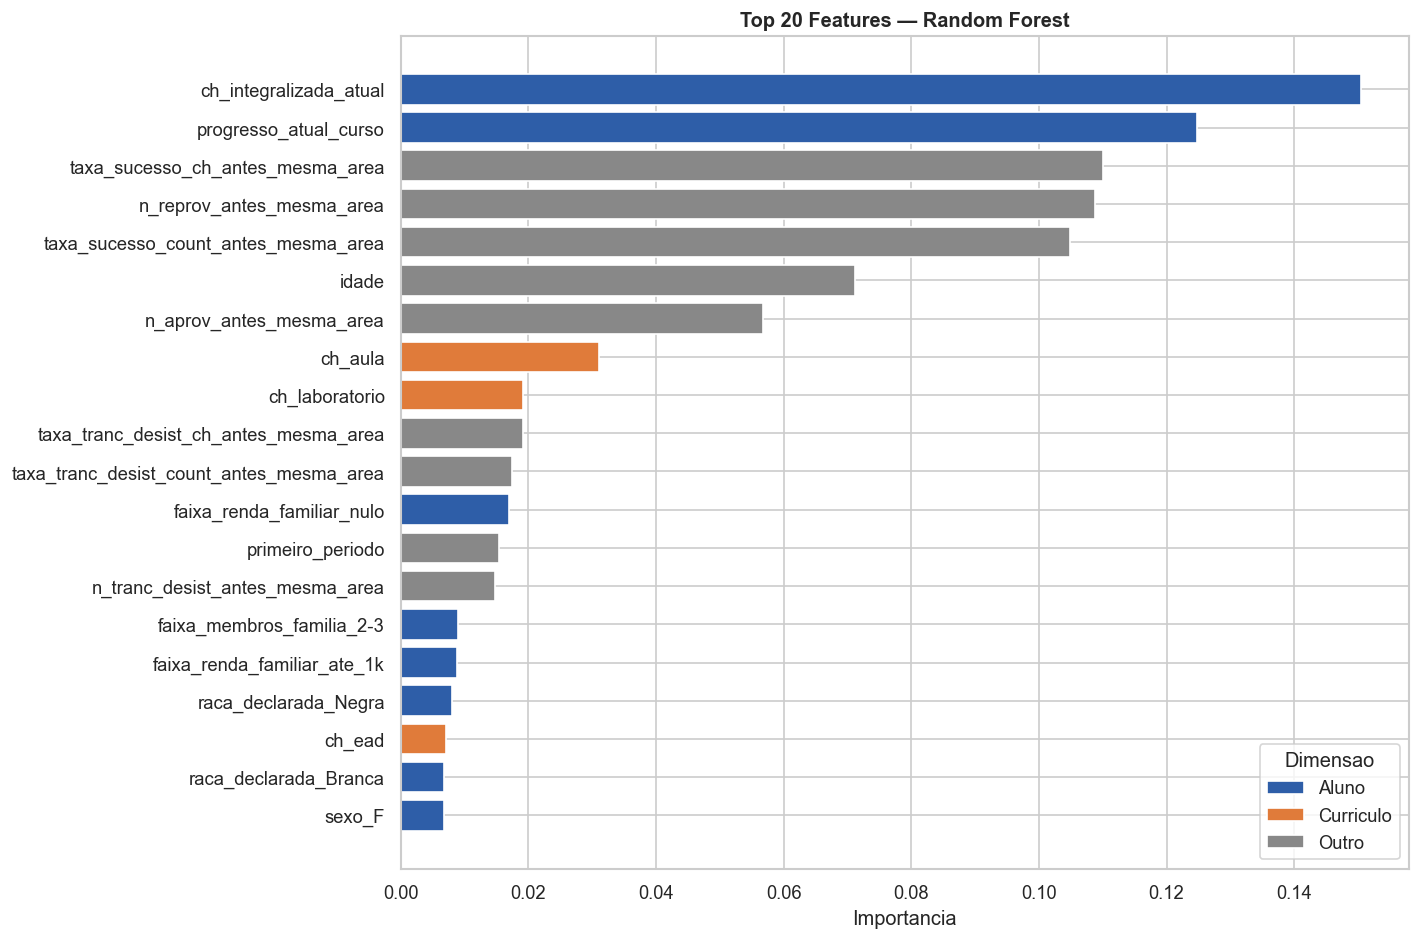


Top 10 features (Random Forest):
  [Aluno               ] ch_integralizada_atual                   0.1504
  [Aluno               ] progresso_atual_curso                    0.1248
  [Outro               ] taxa_sucesso_ch_antes_mesma_area         0.1100
  [Outro               ] n_reprov_antes_mesma_area                0.1088
  [Outro               ] taxa_sucesso_count_antes_mesma_area      0.1048
  [Outro               ] idade                                    0.0711
  [Outro               ] n_aprov_antes_mesma_area                 0.0568
  [Curriculo           ] ch_aula                                  0.0310
  [Curriculo           ] ch_laboratorio                           0.0192
  [Outro               ] taxa_tranc_desist_ch_antes_mesma_area    0.0191
  [Outro               ] taxa_tranc_desist_count_antes_mesma_area 0.0175
  [Aluno               ] faixa_renda_familiar_nulo                0.0170
  [Outro               ] primeiro_periodo                         0.0154
  [Outro         

In [15]:
modelos_arvore = ['Random Forest','XGBoost','Gradient Boosting','Arvore de Decisao']
nome_imp = next((m for m in modelos_arvore if m in pipelines_treinados), None)

if nome_imp:
    pipe_imp = pipelines_treinados[nome_imp]
    clf = pipe_imp.named_steps['classifier']
    prep = pipe_imp.named_steps['preprocessor']

    feat_names_all = FEAT_NUM.copy()
    if FEAT_CAT and 'cat' in prep.named_transformers_:
        ohe = prep.named_transformers_['cat'].named_steps['encoder']
        feat_names_all += list(ohe.get_feature_names_out(FEAT_CAT))

    df_imp = pd.DataFrame({'feature': feat_names_all, 'importancia': clf.feature_importances_})
    df_imp = df_imp.sort_values('importancia', ascending=False).head(20)

    def get_bloco(feat):
        f = feat.lower()
        if any(k in f for k in ['sexo','raca','renda','ingresso','familia','ch_integr','ch_pend','media_g','uf_','progress']):
            return 'Aluno'
        if any(k in f for k in ['ch_total','ch_aula','ch_lab','ch_ead','nivel','tipo_comp','qtd_max','campus','turno','prop_ch']):
            return 'Curriculo'
        if any(k in f for k in ['docentes','feminino','admissao','efetivo']):
            return 'Professor'
        return 'Outro'

    df_imp['bloco'] = df_imp['feature'].apply(get_bloco)
    bcolors = {'Aluno':'#2E5EA8','Curriculo':'#E07B3A','Professor':'#27A04B','Outro':'#888'}

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(df_imp['feature'][::-1], df_imp['importancia'][::-1],
            color=[bcolors[b] for b in df_imp['bloco']][::-1])
    ax.set_xlabel('Importancia')
    ax.set_title(f'Top 20 Features — {nome_imp}', fontweight='bold')
    ax.legend(handles=[Patch(facecolor=c, label=b) for b,c in bcolors.items()
                       if b in df_imp['bloco'].values], title='Dimensao')
    plt.tight_layout()
    plt.savefig('img/fig15_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nTop 10 features ({nome_imp}):')
    for _, row in df_imp.head(30).iterrows():
        print(f'  [{row["bloco"]:20}] {row["feature"]:40} {row["importancia"]:.4f}')

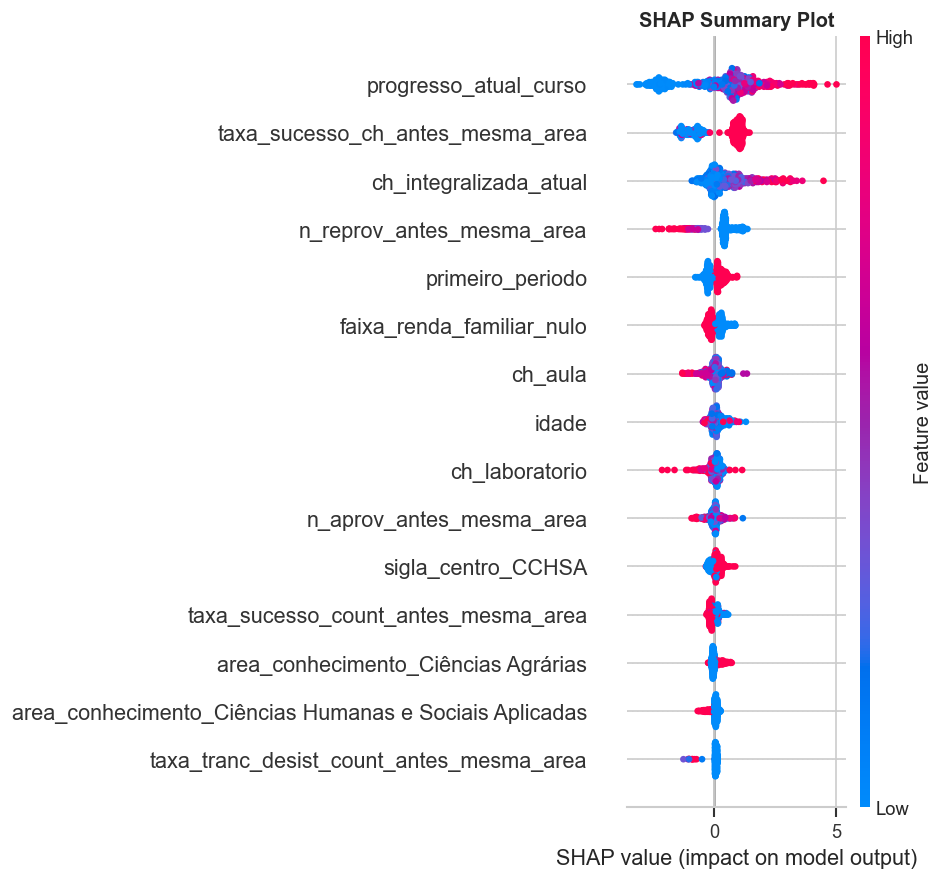

SHAP calculado com sucesso!


In [16]:
try:
    import shap
    pipe_shap = pipelines_treinados.get('XGBoost') or pipelines_treinados.get('Random Forest')
    X_shap = pipe_shap.named_steps['preprocessor'].transform(X_test)[:500]
    explainer   = shap.TreeExplainer(pipe_shap.named_steps['classifier'])
    shap_values = explainer.shap_values(X_shap)
    shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values
    plt.figure(figsize=(11, 8))
    shap.summary_plot(shap_vals, X_shap, feature_names=feat_names_all, max_display=15, show=False)
    plt.title('SHAP Summary Plot', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig16_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP calculado com sucesso!')
except ImportError:
    print('SHAP nao instalado. Execute: pip install shap')
except Exception as e:
    print(f'SHAP indisponivel: {e}')

In [17]:
import shap
import numpy as np
import pandas as pd

pipe = pipelines_treinados['XGBoost']   # ou o nome que estiver no seu dict
X_test_tr = pipe.named_steps['preprocessor'].transform(X_test)
model = pipe.named_steps['classifier']

# nomes das features pós-transformação
feat_names = FEAT_NUM.copy()
if FEAT_CAT and 'cat' in pipe.named_steps['preprocessor'].named_transformers_:
    ohe = pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
    feat_names += list(ohe.get_feature_names_out(FEAT_CAT))

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_tr)
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# índice global de interpretabilidade por variável
shap_global = pd.DataFrame({
    'feature': feat_names,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

display(shap_global.head(20))

,feature,mean_abs_shap
13,progresso_atual_curso,1.261925
9,taxa_sucesso_ch_antes_mesma_area,0.938271
12,ch_integralizada_atual,0.653428
6,n_reprov_antes_mesma_area,0.609307
1,primeiro_periodo,0.264900
29,faixa_renda_familiar_nulo,0.212022
2,ch_aula,0.193295
0,idade,0.183827
3,ch_laboratorio,0.181918
5,n_aprov_antes_mesma_area,0.157369


In [18]:
from sklearn.tree import export_text
import pandas as pd

pipe = pipelines_treinados['Arvore de Decisao']
tree = pipe.named_steps['classifier']
prep = pipe.named_steps['preprocessor']

feat_names = FEAT_NUM.copy()
if FEAT_CAT and 'cat' in prep.named_transformers_:
    ohe = prep.named_transformers_['cat'].named_steps['encoder']
    feat_names += list(ohe.get_feature_names_out(FEAT_CAT))

print('Profundidade:', tree.get_depth())
print('Numero de folhas:', tree.get_n_leaves())

imp_tree = pd.DataFrame({
    'feature': feat_names,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=False)

display(imp_tree.head(20))

print(export_text(tree, feature_names=feat_names, max_depth=3))

Profundidade: 8
Numero de folhas: 196


,feature,importance
9,taxa_sucesso_ch_antes_mesma_area,0.608488
6,n_reprov_antes_mesma_area,0.115858
12,ch_integralizada_atual,0.107747
11,taxa_tranc_desist_ch_antes_mesma_area,0.062721
13,progresso_atual_curso,0.029090
29,faixa_renda_familiar_nulo,0.018325
1,primeiro_periodo,0.009730
36,sigla_centro_CCHSA,0.009223
42,area_conhecimento_Ciências da Saúde,0.005960
5,n_aprov_antes_mesma_area,0.004498


|--- taxa_sucesso_ch_antes_mesma_area <= 0.61
|   |--- ch_integralizada_atual <= -0.78
|   |   |--- faixa_renda_familiar_nulo <= 0.50
|   |   |   |--- n_reprov_antes_mesma_area <= -0.01
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- n_reprov_antes_mesma_area >  -0.01
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- faixa_renda_familiar_nulo >  0.50
|   |   |   |--- n_reprov_antes_mesma_area <= -0.01
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- n_reprov_antes_mesma_area >  -0.01
|   |   |   |   |--- truncated branch of depth 5
|   |--- ch_integralizada_atual >  -0.78
|   |   |--- n_reprov_antes_mesma_area <= -0.01
|   |   |   |--- taxa_tranc_desist_ch_antes_mesma_area <= 3.76
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- taxa_tranc_desist_ch_antes_mesma_area >  3.76
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- n_reprov_antes_mesma_area >  -0.01
|   |   |   |--- progresso_atual_curso <= 1.13
|   |  

## 8. Fechamento da etapa de modelagem e inferência

Encerramos esta etapa com comparação de modelos, seleção do melhor pipeline e geração de escore de risco.
O foco daqui em diante é refino do modelo e operacionalização da inferência.

In [19]:
print('=' * 70)
print(' FECHAMENTO — MODELAGEM E INFERENCIA')
print('=' * 70)
print(f'\nBase de modelagem: {len(df_modelo_tratado):,} registros | {len(ALL_FEATURES)} features')
print('Variavel-alvo: Binaria (Sucesso / Insucesso)')

print('\nRanking dos modelos (F2 + Recall Risco - classe 0):')
df_rank = (
    df_resultados[['Modelo', 'F2-Score Risco (classe 0)', 'Recall Risco (classe 0)', 'Precisao Risco (classe 0)', 'AUC-ROC', 'F2 Risco CV Medio']]
    .sort_values(['F2-Score Risco (classe 0)', 'Recall Risco (classe 0)'], ascending=False)
    .reset_index(drop=True)
)
for idx, row in df_rank.iterrows():
    print(f'  {idx+1}. {row["Modelo"]:<25} F2Risco={row["F2-Score Risco (classe 0)"]:.4f}  RecallRisco={row["Recall Risco (classe 0)"]:.4f}  PrecisaoRisco={row["Precisao Risco (classe 0)"]:.4f}  AUC={row["AUC-ROC"]:.4f}  CV={row["F2 Risco CV Medio"]:.4f}')

print(f'\nModelo recomendado para inferencia: {melhor}')
print('Uso sugerido: gerar probabilidade de sucesso e converter em risco de insucesso (1 - p_sucesso).')

print('\nProximos passos desta trilha:')
print('  1. Calibrar probabilidades para uso institucional de faixas de risco')
print('  2. Definir limiares operacionais por curso/centro (baixo, medio, alto)')
print('  3. Validar estabilidade temporal da inferencia')
print('  4. Empacotar pipeline para execucao recorrente')

 FECHAMENTO — MODELAGEM E INFERENCIA

Base de modelagem: 125,764 registros | 22 features
Variavel-alvo: Binaria (Sucesso / Insucesso)

Ranking dos modelos (F2 + Recall Risco - classe 0):
  1. XGBoost                   F2Risco=0.8512  RecallRisco=0.8817  PrecisaoRisco=0.7478  AUC=0.9616  CV=0.8456
  2. Arvore de Decisao         F2Risco=0.8179  RecallRisco=0.8617  PrecisaoRisco=0.6798  AUC=0.9342  CV=0.8177
  3. Random Forest             F2Risco=0.7855  RecallRisco=0.7752  PrecisaoRisco=0.8296  AUC=0.9564  CV=0.7813
  4. Regressao Logistica       F2Risco=0.7788  RecallRisco=0.8442  PrecisaoRisco=0.5944  AUC=0.9089  CV=0.7781
  5. Gradient Boosting         F2Risco=0.7648  RecallRisco=0.7550  PrecisaoRisco=0.8066  AUC=0.9430  CV=0.7657
  6. Baseline (Dummy)          F2Risco=0.0000  RecallRisco=0.0000  PrecisaoRisco=0.0000  AUC=0.5000  CV=0.0000

Modelo recomendado para inferencia: XGBoost
Uso sugerido: gerar probabilidade de sucesso e converter em risco de insucesso (1 - p_sucesso).

Proxi

In [20]:
# Exportacao de artefatos de inferencia (pickle + template para qualquer aluno)
from inferencia_export import exportar_artefato_inferencia_aluno

_risk = globals().get("risk_df")
risk_opt = _risk.copy() if _risk is not None else None

pickle_path = "artefatos/inferencia_modelagem.pkl"
template_csv = "artefatos/template_inferencia_aluno.csv"

artefato_inferencia = exportar_artefato_inferencia_aluno(
    pipeline_melhor=pipelines_treinados[melhor],
    modelo_nome=melhor,
    all_features=ALL_FEATURES,
    feat_num=FEAT_NUM,
    feat_cat=FEAT_CAT,
    X_referencia=X_train,
    caminho_saida=pickle_path,
    df_resultados=df_resultados,
    X_test=X_test,
    y_test=y_test,
    risk_df=risk_opt,
    template_csv_path=template_csv,
)

print(f"Artefato salvo com sucesso em: {pickle_path}")
print(f"Modelo exportado: {melhor}")
print(f"Template CSV (apenas cabecalho + dtypes no pickle): {template_csv}")

Artefato salvo com sucesso em: artefatos/inferencia_modelagem.pkl
Modelo exportado: XGBoost
Template CSV (apenas cabecalho + dtypes no pickle): artefatos/template_inferencia_aluno.csv


In [21]:
# Fato de risco por matricula (chave composta) — base para dashboard e cruzamentos
import os
from datetime import datetime

import pandas as pd

# Chave composta alinha com o grao da base (sem id_matricula na fonte atual):
# discente x disciplina x ano x periodo letivo.
pipe_final = pipelines_treinados[melhor]
X_full = df_modelo_tratado[ALL_FEATURES]
p_sucesso = pipe_final.predict_proba(X_full)[:, 1]

cols_chave = [
    "id_discente",
    "id_disciplina",
    "ano",
    "periodo",
    "id_curso",
    "id_estrutura_curricular",
]
for c in cols_chave:
    if c not in df_modelo_tratado.columns:
        raise ValueError(f"Coluna ausente em df_modelo_tratado: {c}")

fato = df_modelo_tratado[cols_chave].copy()
fato.insert(0, "id_linha_base", df_modelo_tratado.index.to_numpy())

fato["sk_matricula_composta"] = (
    fato["id_discente"].astype(str)
    + "|"
    + fato["id_disciplina"].astype(str)
    + "|"
    + fato["ano"].astype(str)
    + "|"
    + fato["periodo"].astype(str)
)

for c in ("codigo_componente_curricular", "nome_componete_curricular"):
    if c in df_modelo_tratado.columns:
        fato[c] = df_modelo_tratado[c].values

fato["p_sucesso"] = p_sucesso
fato["p_risco_insucesso"] = 1.0 - p_sucesso
fato["modelo_nome"] = melhor
fato["data_geracao_score"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

if "target" in df_modelo_tratado.columns:
    fato["target_observado"] = df_modelo_tratado["target"].values

# Ordem: chave sintetica, chaves naturais, contexto disciplina, medidas
front = [
    "id_linha_base",
    "sk_matricula_composta",
    "id_discente",
    "id_disciplina",
    "ano",
    "periodo",
    "id_curso",
    "id_estrutura_curricular",
]
rest = [c for c in fato.columns if c not in front]
fato = fato[front + rest]

out_path = os.path.join("dados", "fato_risco_matricula.csv")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fato.to_csv(out_path, index=False)

n_dup = fato["sk_matricula_composta"].duplicated().sum()
print(f"Fato gravado: {out_path} ({len(fato):,} linhas)")
print(f"Chave composta duplicada: {n_dup} (esperado 0)")
print(f"Colunas: {list(fato.columns)}")


Fato gravado: dados\fato_risco_matricula.csv (125,764 linhas)
Chave composta duplicada: 205 (esperado 0)
Colunas: ['id_linha_base', 'sk_matricula_composta', 'id_discente', 'id_disciplina', 'ano', 'periodo', 'id_curso', 'id_estrutura_curricular', 'codigo_componente_curricular', 'nome_componete_curricular', 'p_sucesso', 'p_risco_insucesso', 'modelo_nome', 'data_geracao_score', 'target_observado']
